In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset 2 value.xlsx to Dataset 2 value.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("Dataset 2 value.xlsx")
df.head()

,ID_REF,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
0,1007_s_at,0.888016,1.435518,1.609601,1.754960,1.820730,1.439672,1.587641,0.524710,0.796570,...,1.011327,1.332540,1.750857,0.906644,0.800198,1.411348,1.133052,0.773088,1.092253,0.920046
1,1053_at,0.666460,0.885852,1.859078,1.036666,1.421393,1.485035,1.186292,0.876624,0.917716,...,1.037375,0.881347,0.621852,1.064757,0.948411,0.885746,1.203288,1.000950,0.594889,0.743494
2,117_at,0.859638,1.062030,3.097395,2.243655,5.060301,13.800817,2.211287,0.824494,1.650645,...,0.850823,1.293015,1.586228,0.833373,0.933959,1.466986,0.681689,1.023364,1.271319,0.760213
3,121_at,0.975150,1.050745,0.982284,1.198237,1.039529,0.781454,1.011910,1.151515,0.960083,...,0.789286,1.048424,1.148704,0.871242,0.939254,0.958179,0.759268,1.195609,0.818918,0.760303
4,1255_g_at,0.491255,0.537525,3.179645,1.514290,2.185801,3.541644,2.213126,1.422447,5.011413,...,0.525599,0.938025,4.206879,0.535288,1.379076,1.478383,0.614342,0.554637,0.464429,0.513152


In [ ]:
import pandas as pd

df = pd.read_excel("Dataset 2 value.xlsx")

df.to_csv("Dataset 2.csv", index=False)

print("Converted to CSV successfully")

Converted to CSV successfully


In [ ]:
df.head()

,ID_REF,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
0,1007_s_at,0.888016,1.435518,1.609601,1.754960,1.820730,1.439672,1.587641,0.524710,0.796570,...,1.011327,1.332540,1.750857,0.906644,0.800198,1.411348,1.133052,0.773088,1.092253,0.920046
1,1053_at,0.666460,0.885852,1.859078,1.036666,1.421393,1.485035,1.186292,0.876624,0.917716,...,1.037375,0.881347,0.621852,1.064757,0.948411,0.885746,1.203288,1.000950,0.594889,0.743494
2,117_at,0.859638,1.062030,3.097395,2.243655,5.060301,13.800817,2.211287,0.824494,1.650645,...,0.850823,1.293015,1.586228,0.833373,0.933959,1.466986,0.681689,1.023364,1.271319,0.760213
3,121_at,0.975150,1.050745,0.982284,1.198237,1.039529,0.781454,1.011910,1.151515,0.960083,...,0.789286,1.048424,1.148704,0.871242,0.939254,0.958179,0.759268,1.195609,0.818918,0.760303
4,1255_g_at,0.491255,0.537525,3.179645,1.514290,2.185801,3.541644,2.213126,1.422447,5.011413,...,0.525599,0.938025,4.206879,0.535288,1.379076,1.478383,0.614342,0.554637,0.464429,0.513152


In [ ]:
rows, cols = df.shape
print("Total rows of Test Dataset:", rows)
print("Total columns of Test Dataset:", cols)

Total rows of Test Dataset: 54675
Total columns of Test Dataset: 174


In [ ]:
import pandas as pd
import numpy as np

ids = df["ID_REF"]
data = df.drop(columns=["ID_REF"])

In [ ]:
# Min-Max scaling (row-wise)
expr_scaled = data.sub(data.min(axis=1), axis=0) \
                  .div(data.max(axis=1) - data.min(axis=1), axis=0)

In [ ]:
expr_scaled["ID_REF"] = ids
expr_scaled = expr_scaled.set_index("ID_REF")

In [ ]:
# Keep genes with mean expression > 0.5
expr_filtered = expr_scaled[expr_scaled.mean(axis=1) > 0.5]

print(expr_filtered.shape)

(8646, 173)


In [ ]:
expr_filtered.head(2)

,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,GSM300175,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
ID_REF,,,,,,,,,,,,,,,,,,,,,
1552266_at,0.863292,0.571450,0.059387,0.038547,0.027909,0.039496,0.079279,0.612367,0.564976,0.705348,...,0.742481,0.532620,0.460996,0.830640,0.572790,0.573911,0.561622,0.546432,0.476933,0.719394
1552280_at,0.978596,0.711416,0.014345,0.000000,0.009212,0.000731,0.058119,0.675248,0.594998,0.838996,...,0.663246,0.642015,0.526821,0.728096,0.695331,0.592021,0.817609,0.749671,0.614940,0.700840


In [ ]:
expr_filtered.to_csv("expr_filtered.csv", index=False)
print("Saved Successfully")

Saved Successfully


In [ ]:
samples = list(expr_filtered.columns)

group_map = {}

for i, sample in enumerate(samples):
    if i < 127:
        group_map[sample] = "Control"
    else:
        group_map[sample] = "Disease"

In [ ]:
long_df = (
    expr_filtered
    .reset_index()
    .melt(id_vars="ID_REF", var_name="Sample", value_name="Expression")
)

long_df["Group"] = long_df["Sample"].map(group_map)

In [ ]:
from scipy.stats import ttest_ind

ttest_results = []

for gene in expr_filtered.index:
    row = expr_filtered.loc[gene]

    group1 = row[[s for s in expr_filtered.columns if group_map[s] == "Control"]]
    group2 = row[[s for s in expr_filtered.columns if group_map[s] == "Disease"]]

    stat, pval = ttest_ind(group1, group2, equal_var=False)

    if pval < 0.5:
        ttest_results.append(gene)

ttest_genes = set(ttest_results)
print("T-test genes:", len(ttest_genes))

T-test genes: 5827


In [ ]:
ttest_genes_list = list(ttest_genes)

# Subset expression data for selected genes
selected_expr = expr_filtered.loc[ttest_genes_list]

selected_expr = selected_expr.reset_index()  # Moves gene IDs from index to a column
selected_expr.rename(columns={"index": "Gene"}, inplace=True)

In [ ]:
selected_expr.head(2)

,ID_REF,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
0,227957_at,0.657259,0.691778,0.040091,0.000862,0.020319,0.000000,0.060547,0.662071,0.56339,...,0.656545,0.622696,0.505941,0.686237,0.674563,0.561351,0.581373,0.726257,0.596897,0.6846
1,217068_at,0.691200,0.698160,0.021348,0.000000,0.016454,0.000122,0.056140,0.679486,0.60209,...,0.662610,0.652350,0.532446,0.687768,0.714769,0.684681,0.627405,0.745346,0.600804,0.6836


In [ ]:
selected_expr.to_csv("t-test_genes.csv", index=False)
print("Save Successfully")

Save Successfully


In [ ]:
from scipy.stats import f_oneway

anova_results = []

for gene in expr_filtered.index:
    row = expr_filtered.loc[gene]

    groups = []
    for g in set(group_map.values()):
        samples = [s for s in expr_filtered.columns if group_map[s] == g]
        groups.append(row[samples].values)

    if len(groups) >= 2:
        stat, pval = f_oneway(*groups)
        if pval < 0.5:
            anova_results.append(gene)

anova_genes = set(anova_results)
print("ANOVA genes:", len(anova_genes))

ANOVA genes: 4745


In [ ]:
anova_genes_list = list(anova_genes)

# Subset expression data for selected genes
selected_expr = expr_filtered.loc[anova_genes_list]

selected_expr = selected_expr.reset_index()  # Moves gene IDs from index to a column
selected_expr.rename(columns={"index": "Gene"}, inplace=True)

In [ ]:
selected_expr.to_csv("anova_genes.csv", index=False)
print("Save Successfully")

Save Successfully


In [ ]:
import statsmodels.api as sm

limma_results = []

for gene in expr_filtered.index:

    tmp = long_df[long_df["ID_REF"] == gene].copy()

    # Ensure numeric expression
    tmp["Expression"] = pd.to_numeric(tmp["Expression"], errors="coerce")

    # Drop missing values
    tmp = tmp.dropna(subset=["Expression", "Group"])

    # Skip if less than 2 groups
    if tmp["Group"].nunique() < 2:
        continue

    # Create design matrix
    dummies = pd.get_dummies(tmp["Group"], drop_first=True)

    X = sm.add_constant(dummies.astype(float))
    y = tmp["Expression"].astype(float)

    # Fit model
    model = sm.OLS(y, X).fit()

    # Extract p-value safely (no FutureWarning)
    if len(model.pvalues) > 1:
        pval = model.pvalues.iloc[1]   # safe positional extraction

        if pval < 0.5:
            limma_results.append(gene)

# Convert to set
limma_genes = set(limma_results)

print("LIMMA significant genes:", len(limma_genes))

LIMMA significant genes: 4745


In [ ]:
limma_genes_list = list(limma_genes)
selected_limma_expr = expr_filtered.loc[limma_genes_list]

selected_limma_expr = selected_limma_expr.reset_index()  # Move gene IDs from index to column
selected_limma_expr.rename(columns={"index": "Gene"}, inplace=True)

In [ ]:
selected_expr.to_csv("limma_genes.csv", index=False)
print("Save Successfully")

Save Successfully


In [ ]:
from google.colab import files
uploaded = files.upload()

from google.colab import files
uploaded = files.upload()

from google.colab import files
uploaded = files.upload()

Saving anova_genes.csv to anova_genes.csv


Saving limma_genes.csv to limma_genes.csv


Saving t-test_genes.csv to t-test_genes.csv


/tmp/ipykernel_743/2604317121.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Test', y='Statistic', data=plot_df_long, palette='Set2', showfliers=False, width=0.6)


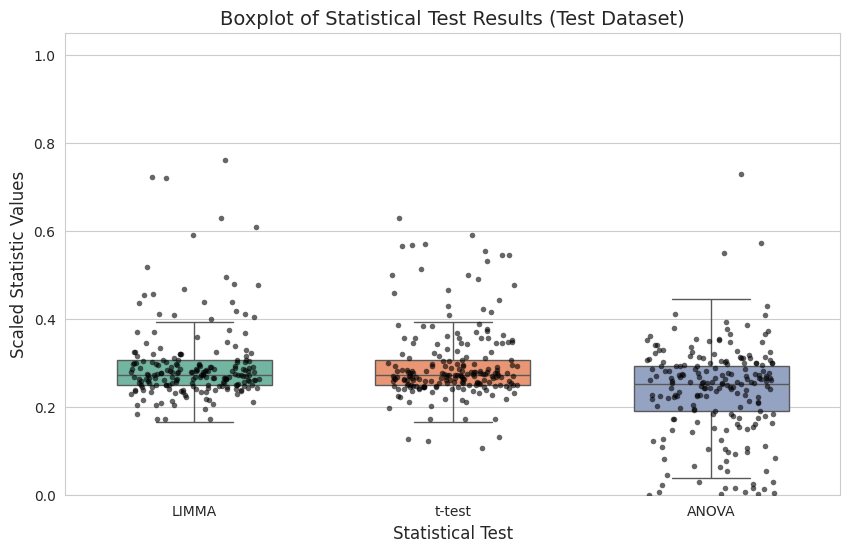

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway
from sklearn.preprocessing import minmax_scale

# -----------------------------
# 1. Load datasets
# -----------------------------
limma_df = pd.read_csv('limma_genes.csv', sep=',').set_index('ID_REF')
ttest_df = pd.read_csv('t-test_genes.csv', sep=',').set_index('ID_REF')
anova_df = pd.read_csv('anova_genes.csv', sep=',').set_index('ID_REF')

# -----------------------------
# 2. Define groups (per dataset)
# -----------------------------
g1_limma = limma_df.columns[:limma_df.shape[1]//2]
g2_limma = limma_df.columns[limma_df.shape[1]//2:]

g1_ttest = ttest_df.columns[:ttest_df.shape[1]//2]
g2_ttest = ttest_df.columns[ttest_df.shape[1]//2:]

g1_anova = anova_df.columns[:anova_df.shape[1]//2]
g2_anova = anova_df.columns[anova_df.shape[1]//2:]

# -----------------------------
# 3. Compute statistics safely
# -----------------------------
def row_ttest(df, g1, g2):
    mean1 = df[g1].mean(axis=1)
    mean2 = df[g2].mean(axis=1)
    std1 = df[g1].std(axis=1, ddof=1)
    std2 = df[g2].std(axis=1, ddof=1)
    n1 = len(g1)
    n2 = len(g2)
    t_values = (mean1 - mean2) / np.sqrt(np.where(std1**2/n1 + std2**2/n2==0, np.nan, std1**2/n1 + std2**2/n2))
    return t_values

def row_anova(df, g1, g2):
    f_values = []
    for row in df.itertuples(index=False):
        group1_vals = row[:len(g1)]
        group2_vals = row[len(g1):]
        if np.var(group1_vals)==0 and np.var(group2_vals)==0:
            f_values.append(np.nan)
        else:
            f_values.append(f_oneway(group1_vals, group2_vals)[0])
    return pd.Series(f_values, index=df.index)

limma_df['Statistic'] = row_ttest(limma_df, g1_limma, g2_limma)
ttest_df['Statistic'] = row_ttest(ttest_df, g1_ttest, g2_ttest)
anova_df['Statistic'] = row_anova(anova_df, g1_anova, g2_anova)

# -----------------------------
# 4. Align by common genes and scale
# -----------------------------
common_genes = limma_df.index.intersection(ttest_df.index).intersection(anova_df.index)

merged_df = pd.DataFrame({
    'LIMMA': minmax_scale(limma_df.loc[common_genes, 'Statistic']),
    't-test': minmax_scale(ttest_df.loc[common_genes, 'Statistic']),
    'ANOVA': minmax_scale(anova_df.loc[common_genes, 'Statistic'])
}, index=common_genes)

plot_df_long = merged_df.reset_index().melt(id_vars='ID_REF', var_name='Test', value_name='Statistic')

# -----------------------------
# 5. Clean boxplot (no numbers)
# -----------------------------
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Boxplot
sns.boxplot(x='Test', y='Statistic', data=plot_df_long, palette='Set2', showfliers=False, width=0.6)

# Overlay sampled points
sampled_df = plot_df_long.groupby('Test').sample(n=min(200, len(plot_df_long)//3), random_state=42)
sns.stripplot(x='Test', y='Statistic', data=sampled_df, color='black', alpha=0.6, jitter=0.25, size=4)

plt.title('Boxplot of Statistical Test Results (Test Dataset)', fontsize=14)
plt.ylabel('Scaled Statistic Values', fontsize=12)
plt.xlabel('Statistical Test', fontsize=12)
plt.ylim(0, 1.05)
plt.show()

/tmp/ipykernel_625/411112301.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Test', y='Statistic', data=plot_df_long, showfliers=True, palette='Set2')


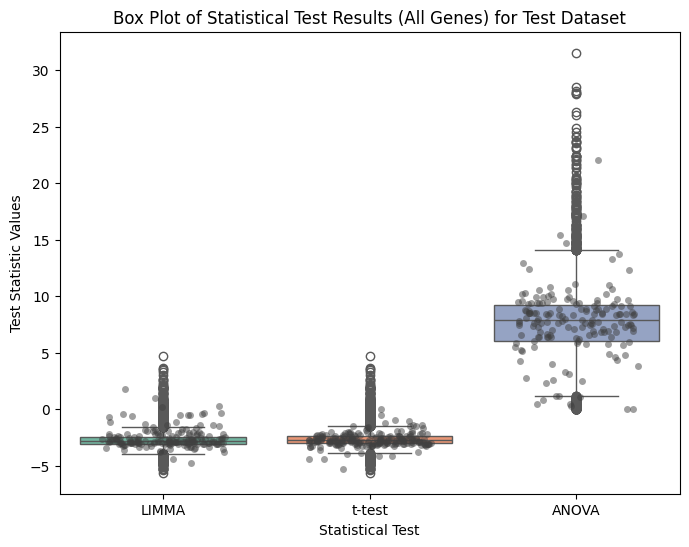

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway

# -----------------------------
# 1. Load datasets
# -----------------------------
limma_df = pd.read_csv('limma_genes.csv', sep=',').set_index('ID_REF')
ttest_df = pd.read_csv('t-test_genes.csv', sep=',').set_index('ID_REF')
anova_df = pd.read_csv('anova_genes.csv', sep=',').set_index('ID_REF')

# -----------------------------
# 2. Define groups
# -----------------------------
group1_cols = limma_df.columns[:limma_df.shape[1]//2]
group2_cols = limma_df.columns[limma_df.shape[1]//2:]

# -----------------------------
# 3. Compute statistics per gene (vectorized)
# -----------------------------
def row_ttest(df, g1, g2):
    # Compute mean and std per row
    mean1 = df[g1].mean(axis=1)
    mean2 = df[g2].mean(axis=1)
    std1 = df[g1].std(axis=1, ddof=1)
    std2 = df[g2].std(axis=1, ddof=1)
    n1 = len(g1)
    n2 = len(g2)
    # Welch's t-test
    t_values = (mean1 - mean2) / np.sqrt(std1**2/n1 + std2**2/n2)
    return t_values

limma_df['Statistic'] = row_ttest(limma_df, group1_cols, group2_cols)
ttest_df['Statistic'] = row_ttest(ttest_df, group1_cols, group2_cols)

# ANOVA F-value per row
def row_anova(df, g1, g2):
    f_values = []
    for row in df.itertuples(index=False):
        f_values.append(f_oneway(row[:len(g1)], row[len(g1):])[0])
    return pd.Series(f_values, index=df.index)

anova_df['Statistic'] = row_anova(anova_df, group1_cols, group2_cols)

# -----------------------------
# 4. Merge statistics
# -----------------------------
merged_df = pd.DataFrame({
    'LIMMA': limma_df['Statistic'],
    't-test': ttest_df['Statistic'],
    'ANOVA': anova_df['Statistic']
})

plot_df_long = merged_df.reset_index().melt(id_vars='ID_REF', var_name='Test', value_name='Statistic')

# -----------------------------
# 5. Plot boxplot with sampled points
# -----------------------------
plt.figure(figsize=(8,6))
sns.boxplot(x='Test', y='Statistic', data=plot_df_long, showfliers=True, palette='Set2')

# Sample points to avoid crowding
sampled_df = plot_df_long.groupby('Test').sample(n=min(200, len(plot_df_long)//3), random_state=42)
sns.stripplot(x='Test', y='Statistic', data=sampled_df, color=".25", alpha=0.5, jitter=0.3)

plt.title('Box Plot of Statistical Test Results (All Genes) for Test Dataset')
plt.ylabel('Test Statistic Values')
plt.xlabel('Statistical Test')
plt.show()

In [ ]:
intersection_genes = ttest_genes & anova_genes & limma_genes

print("Intersection genes:", len(intersection_genes))

Intersection genes: 4740


In [ ]:
# Make sure intersection_genes is a list
genes_list = list(intersection_genes)

# Slice expr_filtered to include these genes and all samples
final_dataset = expr_filtered.loc[genes_list]

# Show first 2 rows and all samples
final_dataset.head(2)

,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,GSM300175,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
ID_REF,,,,,,,,,,,,,,,,,,,,,
208235_x_at,0.616466,0.726633,0.011510,0.000000,0.009234,0.000251,0.039286,0.711596,0.602439,0.650257,...,0.700838,0.650970,0.546820,0.733685,0.689677,0.580749,0.61720,0.766511,0.665375,0.728442
1566760_at,0.705039,0.706460,0.023209,0.014325,0.027700,0.000000,0.069851,0.675363,0.593995,0.617230,...,0.692041,0.686372,0.536754,0.698025,0.710172,0.605865,0.61441,0.742530,0.625555,0.700630


In [ ]:
final_dataset.shape

(4740, 173)

In [ ]:
# Convert index (ID_REF) into a normal column
final_dataset_reset = final_dataset.reset_index()

In [ ]:
# Save to CSV
final_dataset_reset.to_csv("dataset after 3 tests.csv", index=False)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Human TF.xlsx to Human TF.xlsx


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Gene_ID_to_symbol.xlsx to Gene_ID_to_symbol.xlsx


In [ ]:
import pandas as pd

human_tf = pd.read_excel("Human TF.xlsx", header=None)
genes_df = pd.read_excel("Gene_ID_to_symbol.xlsx")

human_tf.to_csv("Human TF.csv", index=False)
genes_df.to_csv("Gene_ID_to_symbol.csv", index=False)

In [ ]:
human_tf = human_tf[[human_tf.columns[0]]]

In [ ]:
print(genes_df.columns)

Index(['From', 'To', 'Species', 'Gene Name'], dtype='object')


In [ ]:
genes_df = genes_df[["To"]]
genes_df.columns = ["GeneSymbol"]

In [ ]:
human_tf = human_tf.iloc[:, [0]]
human_tf.columns = ["GeneSymbol"]

In [ ]:
human_tf["GeneSymbol"] = (
    human_tf["GeneSymbol"]
    .astype(str)
    .str.upper()
    .str.strip()
)

genes_df["GeneSymbol"] = (
    genes_df["GeneSymbol"]
    .astype(str)
    .str.upper()
    .str.strip()
)

In [ ]:
human_tf["GeneSymbol"] = human_tf["GeneSymbol"].str.split(".").str[0]
genes_df["GeneSymbol"] = genes_df["GeneSymbol"].str.split(".").str[0]

In [ ]:
tf_set = set(human_tf["GeneSymbol"])
gene_set = set(genes_df["GeneSymbol"])

overlap = tf_set & gene_set

overlap_df = pd.DataFrame(list(overlap), columns=["GeneSymbol"])

In [ ]:
genes_df = pd.read_excel("Gene_ID_to_symbol.xlsx")

In [ ]:
overlap_df = genes_df.merge(
    human_tf,
    left_on="To",
    right_on="GeneSymbol",
    how="inner"
)

In [ ]:
print("Total TFs:", len(tf_set))
print("Total Genes (To column):", len(gene_set))
print("Overlapping TFs:", len(overlap_df))

Total TFs: 1640
Total Genes (To column): 3889
Overlapping TFs: 326


In [ ]:
# Keep only relevant columns
overlap_final = overlap_df[["From", "To"]]

# Save to CSV
overlap_final.to_csv("Overlapping_TF_Genes.csv", index=False)

In [ ]:
final_dataset_reset.columns

Index(['ID_REF', 'GSM300166', 'GSM300167', 'GSM300168', 'GSM300169',
       'GSM300170', 'GSM300171', 'GSM300172', 'GSM300173', 'GSM300174',
       ...
       'GSM300331', 'GSM300332', 'GSM300333', 'GSM300335', 'GSM300338',
       'GSM300339', 'GSM300340', 'GSM300341', 'GSM318840', 'GSM350078'],
      dtype='object', length=174)

In [ ]:
merged_df = final_dataset_reset.merge(
    overlap_final[["From", "To"]],
    left_on="ID_REF",
    right_on="From",
    how="inner"
)

In [ ]:
merged_df = merged_df.drop(columns=["From"])

In [ ]:
# Get all columns
cols = merged_df.columns.tolist()

# Remove 'To' from current position
cols.remove("To")

# Insert 'To' right after 'ID_REF'
id_index = cols.index("ID_REF")
cols.insert(id_index + 1, "To")

# Reorder dataframe
merged_df = merged_df[cols]

In [ ]:
merged_df.head()

,ID_REF,To,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
0,200828_s_at,ZNF207,0.267584,0.178794,0.539461,0.253034,0.372133,0.844128,0.210750,0.539172,...,0.704964,0.321768,0.379131,0.466293,0.617383,0.706654,0.852981,0.778148,0.238456,0.107685
1,224889_at,FOXO3,0.369413,0.484146,0.237630,0.138226,0.256637,0.266182,0.090729,0.498188,...,0.618634,0.448127,0.324988,0.717596,0.415090,0.312357,0.801722,0.904419,0.614879,0.541017
2,1562305_x_at,ZKSCAN3,0.695904,0.701112,0.023096,0.000000,0.018895,0.001638,0.085026,0.677434,...,0.639034,0.637562,0.522854,0.700102,0.694263,0.719921,0.604926,1.000000,0.608222,0.694458
3,211193_at,TP63,0.618755,0.815235,0.018191,0.009376,0.017125,0.000000,0.044813,0.588005,...,0.790599,0.531824,0.456805,0.824822,0.579361,0.494981,0.591963,0.848069,0.750146,0.821095
4,219780_at,ZNF771,0.598975,0.654656,0.019051,0.000100,0.013276,0.000000,0.040277,0.614608,...,0.631770,0.585692,0.475648,0.657721,0.620419,0.514894,0.562490,0.686705,0.588224,0.672016


In [ ]:
merged_df.to_csv("TF_with_ID_&_symbol.csv", index=False)

In [ ]:
final_no_id = merged_df.drop(columns=["ID_REF"])
final_no_id = final_no_id.rename(columns={"To": "Symbol"})
final_no_id.head()

,Symbol,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
0,ZNF207,0.267584,0.178794,0.539461,0.253034,0.372133,0.844128,0.210750,0.539172,0.433759,...,0.704964,0.321768,0.379131,0.466293,0.617383,0.706654,0.852981,0.778148,0.238456,0.107685
1,FOXO3,0.369413,0.484146,0.237630,0.138226,0.256637,0.266182,0.090729,0.498188,0.134137,...,0.618634,0.448127,0.324988,0.717596,0.415090,0.312357,0.801722,0.904419,0.614879,0.541017
2,ZKSCAN3,0.695904,0.701112,0.023096,0.000000,0.018895,0.001638,0.085026,0.677434,0.595114,...,0.639034,0.637562,0.522854,0.700102,0.694263,0.719921,0.604926,1.000000,0.608222,0.694458
3,TP63,0.618755,0.815235,0.018191,0.009376,0.017125,0.000000,0.044813,0.588005,0.503171,...,0.790599,0.531824,0.456805,0.824822,0.579361,0.494981,0.591963,0.848069,0.750146,0.821095
4,ZNF771,0.598975,0.654656,0.019051,0.000100,0.013276,0.000000,0.040277,0.614608,0.528830,...,0.631770,0.585692,0.475648,0.657721,0.620419,0.514894,0.562490,0.686705,0.588224,0.672016


In [ ]:
final_no_id.to_csv("TF_expr_symbol.csv", index=False)

In [ ]:
import pandas as pd

TF_expr_symbol = pd.read_csv("TF_expr_symbol.csv")

In [ ]:
print(TF_expr_symbol.shape)

(193, 174)


In [ ]:
# Set gene symbol as index
expr = TF_expr_symbol.set_index("Symbol")

# Compute Pearson correlation (gene–gene)
corr_matrix = expr.T.corr(method="pearson")

# Threshold
import numpy as np
adj_matrix = (corr_matrix >= 0.7).astype(int)

# Remove self-loops
np.fill_diagonal(adj_matrix.values, 0)

In [ ]:
adj_matrix.shape

(193, 193)

In [ ]:
adj_matrix.to_csv("TF_adjacency_matrix.csv")

In [ ]:
# Remove index/column names to avoid conflict
adj_matrix.index.name = None
adj_matrix.columns.name = None

# Stack
edges = adj_matrix.stack().reset_index()

# Keep only edges = 1
edges = edges[edges[0] == 1]

# Rename columns
edges.columns = ["Source", "Target", "Weight"]

# Remove self-loops
edges = edges[edges["Source"] != edges["Target"]]

# Keep upper triangle only (undirected network)
edges = edges[edges["Source"] < edges["Target"]]

# Final edge list
edge_df = edges[["Source", "Target"]]

print("Total edges:", len(edge_df))
edge_df.head()

Total edges: 13742


,Source,Target
390,ZKSCAN3,ZNF771
394,ZKSCAN3,ZSCAN4
398,ZKSCAN3,ZNF777
403,ZKSCAN3,ZNF316
411,ZKSCAN3,ZNF852


In [ ]:
edge_df.to_csv("TF_edge_list.csv", index=False)